In [1]:
import os
import sys
import matplotlib.pyplot as plt
# Get project root (one level above notebooks/)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add project root to Python path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
from src.data_quality import run_quality_checks
from src.generate_report import generate_report
from src.load_data import load_data

In [19]:
# Run quality checks
run_quality_checks()

# Generate KPI report
df, monthly_revenue, top_products, top_10_countries = generate_report()


Data quality report generated.
Sales KPI report generated successfully.


## Plot 1 — Monthly Revenue Trend (Line Chart)

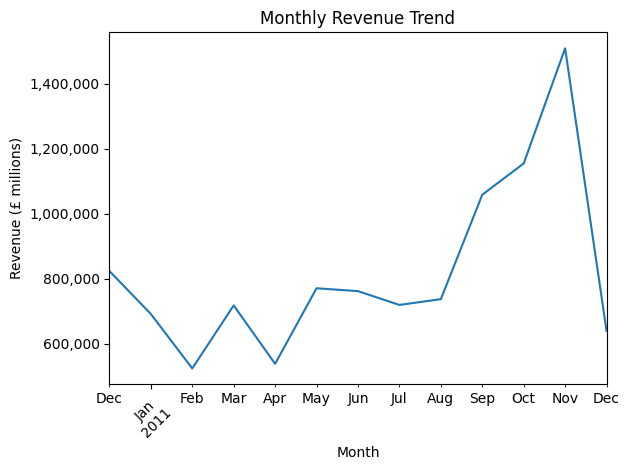

In [22]:
import matplotlib.ticker as ticker

plt.figure()
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£ millions)")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Plot 2 — Top 10 Products (Bar Chart)

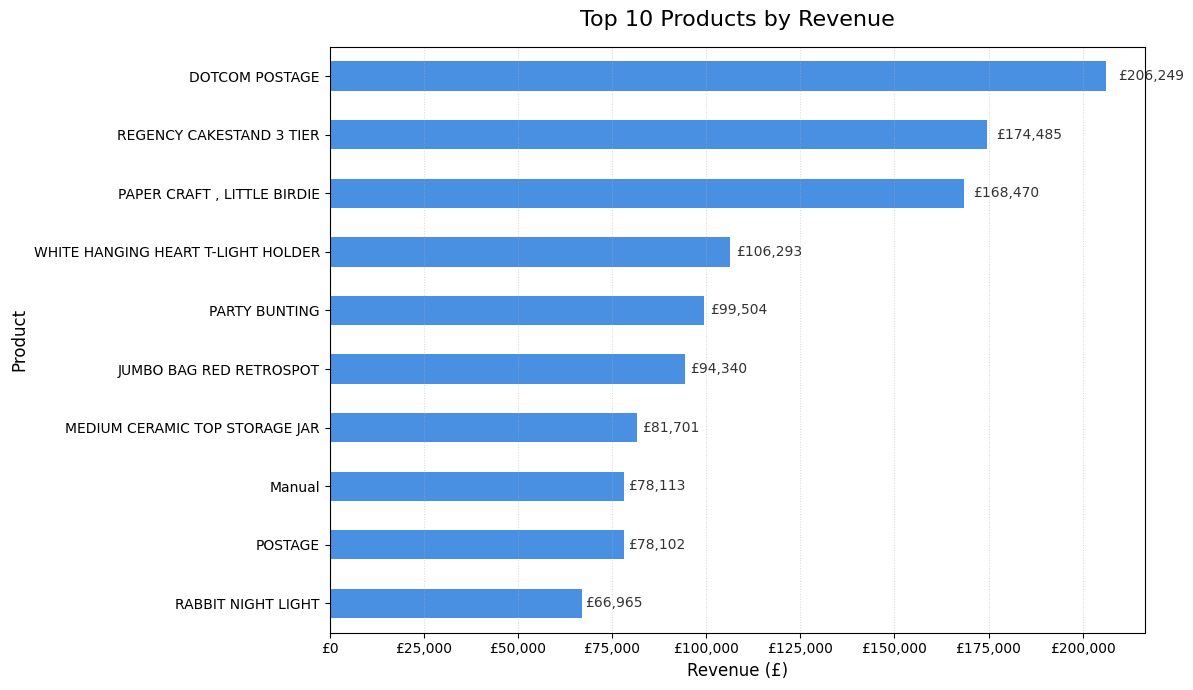

In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Sort for bottom‑to‑top ordering
data = top_products.sort_values()

plt.figure(figsize=(12, 7))

ax = data.plot(
    kind="barh",
    color="#4A90E2",      # modern, readable blue
    edgecolor="none"
)

plt.title("Top 10 Products by Revenue", fontsize=16, pad=15)
plt.xlabel("Revenue (£)", fontsize=12)
plt.ylabel("Product", fontsize=12)

# Light grid for readability
plt.grid(axis="x", linestyle=":", linewidth=0.7, alpha=0.5)

# Format x-axis ticks as currency
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("£{x:,.0f}"))

# Add value labels to the right of each bar
for i, v in enumerate(data):
    ax.text(
        v + (v * 0.015),   # small offset to the right
        i,
        f"£{v:,.0f}",
        va="center",
        ha="left",
        fontsize=10,
        color="#333333"
    )

plt.tight_layout()
plt.savefig("../outputs/top_10_products.png", dpi=200)
plt.show()



## Plot 3 — Top 10 Countries

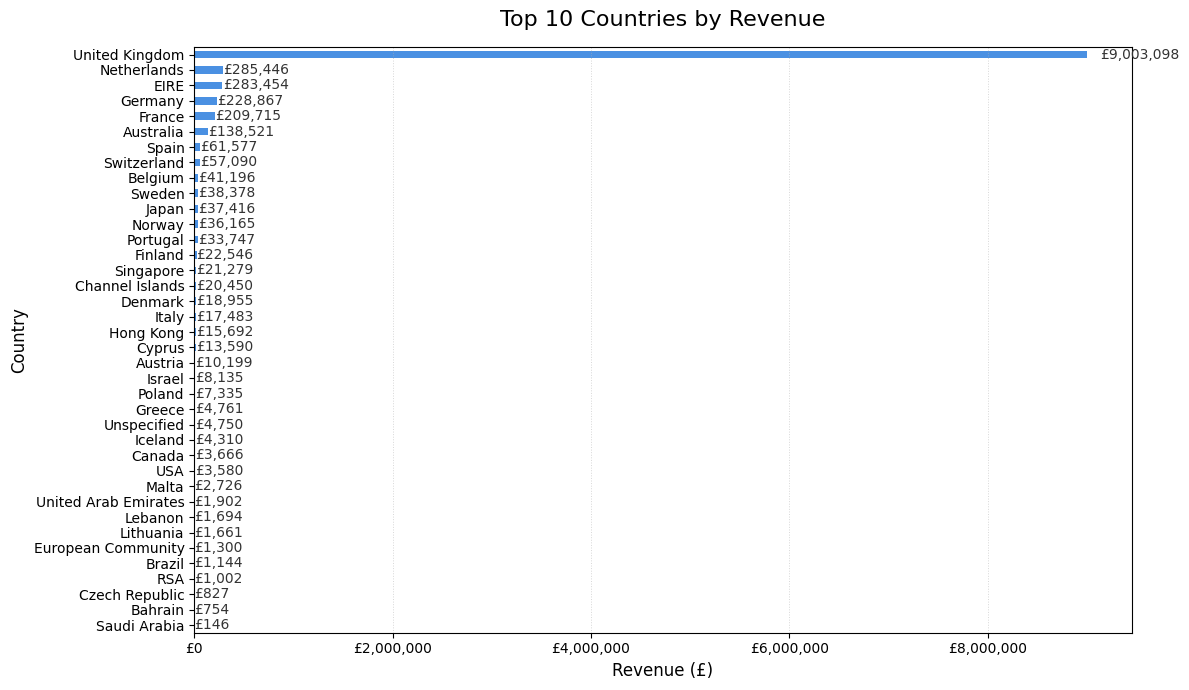

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Sort values for clean bottom-to-top ordering
data = top_10_countries.sort_values()

plt.figure(figsize=(12, 7))

ax = data.plot(
    kind="barh",
    color="#4A90E2",        # softer, modern blue
    edgecolor="none"
)

plt.title("Top 10 Countries by Revenue", fontsize=16, pad=15)
plt.xlabel("Revenue (£)", fontsize=12)
plt.ylabel("Country", fontsize=12)

# Light grid for readability
plt.grid(axis="x", linestyle=":", linewidth=0.7, alpha=0.5)

# Format x-axis ticks as £ with commas
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("£{x:,.0f}"))

# Add value labels to the right of each bar
for i, v in enumerate(data):
    ax.text(
        v + (v * 0.015),     # small offset to the right
        i,
        f"£{v:,.0f}",
        va="center",
        ha="left",
        fontsize=10,
        color="#333333"
    )

# Reduce bar thickness for a cleaner look
ax.bar_label(ax.containers[0], labels=[""] * len(data))  # ensures spacing is correct

plt.tight_layout()
plt.savefig("../outputs/top_10_countries.png", dpi=200)
plt.show()